In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/tabular-playground-series-mar-2022/sample_submission.csv
/kaggle/input/competitions/tabular-playground-series-mar-2022/train.csv
/kaggle/input/competitions/tabular-playground-series-mar-2022/test.csv


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    PolynomialFeatures
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

# ============================================================
# FILE PATHS
# ============================================================

TRAIN_PATH = "/kaggle/input/competitions/tabular-playground-series-mar-2022/train.csv"
TEST_PATH = "/kaggle/input/competitions/tabular-playground-series-mar-2022/test.csv"
SAMPLE_PATH = "/kaggle/input/competitions/tabular-playground-series-mar-2022/sample_submission.csv"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_PATH)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

display(train.head())
display(test.head())


Train shape: (848835, 6)
Test shape: (2340, 5)
Sample submission shape: (2340, 2)


,row_id,time,x,y,direction,congestion
0,0,1991-04-01 00:00:00,0,0,EB,70
1,1,1991-04-01 00:00:00,0,0,NB,49
2,2,1991-04-01 00:00:00,0,0,SB,24
3,3,1991-04-01 00:00:00,0,1,EB,18
4,4,1991-04-01 00:00:00,0,1,NB,60


,row_id,time,x,y,direction
0,848835,1991-09-30 12:00:00,0,0,EB
1,848836,1991-09-30 12:00:00,0,0,NB
2,848837,1991-09-30 12:00:00,0,0,SB
3,848838,1991-09-30 12:00:00,0,1,EB
4,848839,1991-09-30 12:00:00,0,1,NB


In [3]:
print("TRAIN INFO")
print("=" * 60)
train.info()

print("\n\nTEST INFO")
print("=" * 60)
test.info()

print("\nMissing values in train:")
display(train.isnull().sum())

print("\nMissing values in test:")
display(test.isnull().sum())

print("\nDuplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in test:", test.duplicated().sum())


TRAIN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 848835 entries, 0 to 848834
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   row_id      848835 non-null  int64 
 1   time        848835 non-null  object
 2   x           848835 non-null  int64 
 3   y           848835 non-null  int64 
 4   direction   848835 non-null  object
 5   congestion  848835 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 38.9+ MB


TEST INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2340 entries, 0 to 2339
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   row_id     2340 non-null   int64 
 1   time       2340 non-null   object
 2   x          2340 non-null   int64 
 3   y          2340 non-null   int64 
 4   direction  2340 non-null   object
dtypes: int64(3), object(2)
memory usage: 91.5+ KB

Missing values in train:


row_id        0
time          0
x             0
y             0
direction     0
congestion    0
dtype: int64


Missing values in test:


row_id       0
time         0
x            0
y            0
direction    0
dtype: int64


Duplicate rows in train: 0
Duplicate rows in test: 0


In [4]:
print(train["congestion"].describe())

print("\nTarget unique values:", train["congestion"].nunique())
print("Minimum:", train["congestion"].min())
print("Maximum:", train["congestion"].max())


count    848835.000000
mean         47.815305
std          16.799392
min           0.000000
25%          35.000000
50%          47.000000
75%          60.000000
max         100.000000
Name: congestion, dtype: float64

Target unique values: 101
Minimum: 0
Maximum: 100


In [5]:
# Make copies
train = train.copy()
test = test.copy()

# ------------------------------------------------------------
# Remove exact duplicate rows
# ------------------------------------------------------------

train = train.drop_duplicates().reset_index(drop=True)
test = test.drop_duplicates().reset_index(drop=True)

# ------------------------------------------------------------
# Convert time
# ------------------------------------------------------------

train["time"] = pd.to_datetime(train["time"], errors="coerce")
test["time"] = pd.to_datetime(test["time"], errors="coerce")

# ------------------------------------------------------------
# Clean direction
# ------------------------------------------------------------

train["direction"] = train["direction"].astype(str).str.strip().str.upper()
test["direction"] = test["direction"].astype(str).str.strip().str.upper()

# ------------------------------------------------------------
# Numeric conversion
# ------------------------------------------------------------

for col in ["x", "y", "congestion"]:
    if col in train.columns:
        train[col] = pd.to_numeric(train[col], errors="coerce")

for col in ["x", "y"]:
    test[col] = pd.to_numeric(test[col], errors="coerce")

# ------------------------------------------------------------
# Remove rows with invalid essential information
# ------------------------------------------------------------

train = train.dropna(
    subset=["time", "x", "y", "direction", "congestion"]
).reset_index(drop=True)

test = test.dropna(
    subset=["time", "x", "y", "direction"]
).reset_index(drop=True)

# ------------------------------------------------------------
# Target sanity check
# ------------------------------------------------------------

train = train[
    (train["congestion"] >= 0) &
    (train["congestion"] <= 100)
].reset_index(drop=True)

print("Clean train shape:", train.shape)
print("Clean test shape:", test.shape)

print("\nRemaining missing values:")
print(train.isnull().sum())


Clean train shape: (848835, 6)
Clean test shape: (2340, 5)

Remaining missing values:
row_id        0
time          0
x             0
y             0
direction     0
congestion    0
dtype: int64


In [6]:
def create_features(df):
    df = df.copy()

    # ========================================================
    # TIME FEATURES
    # ========================================================

    df["hour"] = df["time"].dt.hour
    df["minute"] = df["time"].dt.minute

    df["day"] = df["time"].dt.day
    df["month"] = df["time"].dt.month
    df["dayofweek"] = df["time"].dt.dayofweek
    df["dayofyear"] = df["time"].dt.dayofyear
    df["weekofyear"] = df["time"].dt.isocalendar().week.astype(int)

    # 0, 1, 2, ... 71
    # because there are 72 twenty-minute periods per day
    df["time_slot"] = (
        df["hour"] * 3 +
        df["minute"] // 20
    )

    # ========================================================
    # CYCLIC TIME FEATURES
    # ========================================================

    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    df["time_slot_sin"] = np.sin(
        2 * np.pi * df["time_slot"] / 72
    )

    df["time_slot_cos"] = np.cos(
        2 * np.pi * df["time_slot"] / 72
    )

    df["dow_sin"] = np.sin(
        2 * np.pi * df["dayofweek"] / 7
    )

    df["dow_cos"] = np.cos(
        2 * np.pi * df["dayofweek"] / 7
    )

    # ========================================================
    # ROAD IDENTIFIER
    # ========================================================

    df["road"] = (
        df["x"].astype(str)
        + "_"
        + df["y"].astype(str)
        + "_"
        + df["direction"]
    )

    return df


train = create_features(train)
test = create_features(test)

display(train.head())


,row_id,time,x,y,direction,congestion,hour,minute,day,month,...,dayofyear,weekofyear,time_slot,hour_sin,hour_cos,time_slot_sin,time_slot_cos,dow_sin,dow_cos,road
0,0,1991-04-01,0,0,EB,70,0,0,1,4,...,91,14,0,0.0,1.0,0.0,1.0,0.0,1.0,0_0_EB
1,1,1991-04-01,0,0,NB,49,0,0,1,4,...,91,14,0,0.0,1.0,0.0,1.0,0.0,1.0,0_0_NB
2,2,1991-04-01,0,0,SB,24,0,0,1,4,...,91,14,0,0.0,1.0,0.0,1.0,0.0,1.0,0_0_SB
3,3,1991-04-01,0,1,EB,18,0,0,1,4,...,91,14,0,0.0,1.0,0.0,1.0,0.0,1.0,0_1_EB
4,4,1991-04-01,0,1,NB,60,0,0,1,4,...,91,14,0,0.0,1.0,0.0,1.0,0.0,1.0,0_1_NB


In [8]:
# ------------------------------------------------------------
# Road-level historical statistics
# ------------------------------------------------------------

road_stats = train.groupby("road")["congestion"].agg(
    road_mean="mean",
    road_median="median",
    road_std="std"
)

# ------------------------------------------------------------
# Road + time-of-day statistics
# ------------------------------------------------------------

road_time_stats = train.groupby(
    ["road", "time_slot"]
)["congestion"].agg(
    road_time_mean="mean",
    road_time_median="median",
    road_time_std="std"
)

# ------------------------------------------------------------
# Day-of-week + time-slot statistics
# ------------------------------------------------------------

dow_time_stats = train.groupby(
    ["dayofweek", "time_slot"]
)["congestion"].agg(
    dow_time_mean="mean",
    dow_time_median="median"
)


In [9]:
def add_historical_features(df):
    df = df.copy()

    # Road statistics
    df = df.join(road_stats, on="road")

    # Road + time statistics
    df = df.join(
        road_time_stats,
        on=["road", "time_slot"]
    )

    # Day-of-week + time statistics
    df = df.join(
        dow_time_stats,
        on=["dayofweek", "time_slot"]
    )

    return df


train = add_historical_features(train)
test = add_historical_features(test)

print(train.shape)
display(train.head())


(848835, 29)


,row_id,time,x,y,direction,congestion,hour,minute,day,month,...,dow_cos,road,road_mean,road_median,road_std,road_time_mean,road_time_median,road_time_std,dow_time_mean,dow_time_median
0,0,1991-04-01,0,0,EB,70,0,0,1,4,...,1.0,0_0_EB,47.396202,47.0,12.554089,40.688525,38.0,10.254253,41.271225,41.0
1,1,1991-04-01,0,0,NB,49,0,0,1,4,...,1.0,0_0_NB,39.513286,39.0,10.355662,36.131148,36.0,12.336592,41.271225,41.0
2,2,1991-04-01,0,0,SB,24,0,0,1,4,...,1.0,0_0_SB,49.864155,51.0,13.688852,42.901639,24.0,21.974289,41.271225,41.0
3,3,1991-04-01,0,1,EB,18,0,0,1,4,...,1.0,0_1_EB,26.942492,27.0,8.287600,20.524590,21.0,7.228469,41.271225,41.0
4,4,1991-04-01,0,1,NB,60,0,0,1,4,...,1.0,0_1_NB,68.888429,70.0,9.517324,66.551913,67.0,6.700524,41.271225,41.0


In [10]:
feature_missing = train.isnull().sum()

display(
    feature_missing[feature_missing > 0]
    .sort_values(ascending=False)
)


Series([], dtype: int64)

In [11]:
numeric_features = [
    "x",
    "y",

    "hour",
    "minute",
    "day",
    "month",
    "dayofweek",
    "dayofyear",
    "weekofyear",
    "time_slot",

    "hour_sin",
    "hour_cos",
    "time_slot_sin",
    "time_slot_cos",
    "dow_sin",
    "dow_cos",

    "road_mean",
    "road_median",
    "road_std",

    "road_time_mean",
    "road_time_median",
    "road_time_std",

    "dow_time_mean",
    "dow_time_median"
]

categorical_features = [
    "direction",
    "road"
]

features = numeric_features + categorical_features

X = train[features]
y = train["congestion"]

X_test = test[features]

print("Number of features:", len(features))


Number of features: 26


In [12]:
# Sort chronologically
train_sorted = train.sort_values("time").reset_index(drop=True)

split_index = int(len(train_sorted) * 0.80)

train_part = train_sorted.iloc[:split_index]
valid_part = train_sorted.iloc[split_index:]

X_train = train_part[features]
y_train = train_part["congestion"]

X_valid = valid_part[features]
y_valid = valid_part["congestion"]

print("Training rows:", len(X_train))
print("Validation rows:", len(X_valid))

print("\nTraining period:")
print(train_part["time"].min(), "to", train_part["time"].max())

print("\nValidation period:")
print(valid_part["time"].min(), "to", valid_part["time"].max())


Training rows: 679068
Validation rows: 169767

Training period:
1991-04-01 00:00:00 to 1991-08-24 12:40:00

Validation period:
1991-08-24 12:40:00 to 1991-09-30 11:40:00


In [14]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [15]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_valid)

linear_mae = mean_absolute_error(
    y_valid,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(y_valid, linear_pred)
)

linear_r2 = r2_score(
    y_valid,
    linear_pred
)

print("MULTIPLE LINEAR REGRESSION")
print("=" * 50)
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)


MULTIPLE LINEAR REGRESSION
MAE : 6.8033592229881945
RMSE: 9.513710669731726
R²  : 0.6753568161397889


In [18]:


poly_numeric = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(
            degree=2,
            include_bias=False
        ))
    ]
)

poly_categorical = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

poly_preprocessor = ColumnTransformer(
    transformers=[
        ("num", poly_numeric, numeric_features),
        ("cat", poly_categorical, categorical_features)
    ]
)


In [19]:
polynomial_model = Pipeline(
    steps=[
        ("preprocessor", poly_preprocessor),
        ("model", LinearRegression())
    ]
)

polynomial_model.fit(X_train, y_train)

poly_pred = polynomial_model.predict(X_valid)

poly_mae = mean_absolute_error(
    y_valid,
    poly_pred
)

poly_rmse = np.sqrt(
    mean_squared_error(y_valid, poly_pred)
)

poly_r2 = r2_score(
    y_valid,
    poly_pred
)

print("POLYNOMIAL REGRESSION")
print("=" * 50)
print("MAE :", poly_mae)
print("RMSE:", poly_rmse)
print("R²  :", poly_r2)


POLYNOMIAL REGRESSION
MAE : 6.923202204396402
RMSE: 9.614507473894928
R²  : 0.6684412508077968


In [21]:
results = pd.DataFrame({
    "Model": [
        "Multiple Linear Regression",
        "Polynomial Regression",
    ],
    "MAE": [
        linear_mae,
        poly_mae,
    ],
    "RMSE": [
        linear_rmse,
        poly_rmse
    ],
    "R2": [
        linear_r2,
        poly_r2
    ]
})

results = results.sort_values("MAE")

display(results)


,Model,MAE,RMSE,R2
0,Multiple Linear Regression,6.803359,9.513711,0.675357
1,Polynomial Regression,6.923202,9.614507,0.668441


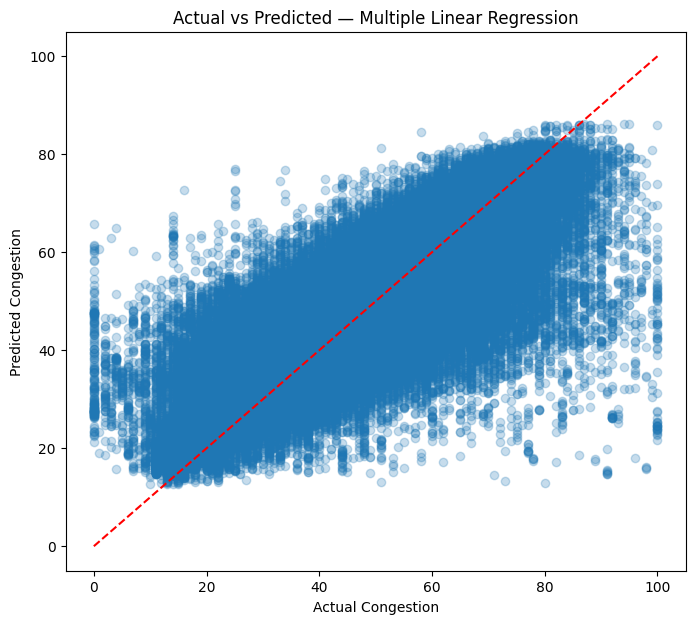

In [22]:
best_pred = {
    "Multiple Linear Regression": linear_pred,
    "Polynomial Regression": poly_pred
}

best_model_name = results.iloc[0]["Model"]
best_predictions = best_pred[best_model_name]

plt.figure(figsize=(8, 7))

plt.scatter(
    y_valid,
    best_predictions,
    alpha=0.25
)

plt.xlabel("Actual Congestion")
plt.ylabel("Predicted Congestion")
plt.title(f"Actual vs Predicted — {best_model_name}")

plt.plot(
    [0, 100],
    [0, 100],
    color="red",
    linestyle="--"
)

plt.show()
